In [55]:
import pandas as pd

In [56]:
import pandas as pd


In [57]:
df_2 = pd.read_csv('../pam/output/dump/device_2.csv')
df_3 = pd.read_csv('../pam/output/dump/device_3.csv')
df_5 = pd.read_csv('../pam/output/dump/device_5.csv')
df_8 = pd.read_csv('../pam/output/dump/device_8.csv')

# Combine them into a single DataFrame
combined_df = pd.concat([df_2, df_3, df_5, df_8], ignore_index=True)

# View the result
combined_df

,Timestamp,Steps,PAM Score
0,2025-05-21 16:28:00,0,0.5625
1,2025-05-21 16:29:00,10,1.0000
2,2025-05-21 17:12:00,44,5.9375
3,2025-05-21 17:13:00,0,0.3750
4,2025-05-21 17:14:00,0,0.0000
...,...,...,...
3345,2025-05-26 11:32:00,0,0.0000
3346,2025-05-26 11:44:00,0,0.3125
3347,2025-05-26 11:45:00,8,1.2500
3348,2025-05-26 11:46:00,50,4.0625


In [58]:
# combined_df['Timestamp'] = pd.to_datetime(combined_df['Timestamp'])
combined_df = combined_df.drop(columns=['Timestamp'])

In [59]:

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

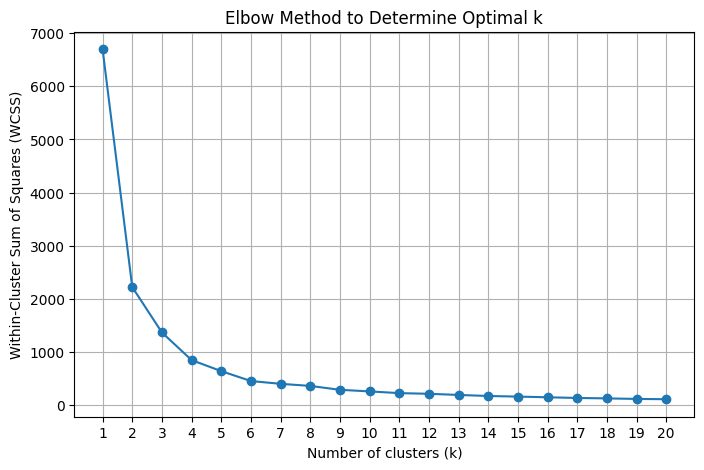

In [60]:
# Keep only numeric columns
numeric_df = combined_df.select_dtypes(include='number')

# Standardize the data
scaler = StandardScaler()
scaled_data = scaler.fit_transform(numeric_df)

# Elbow method
wcss = []
K = range(1, 21)  # Try cluster analysis from 1 to 20 clusters

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(scaled_data)
    wcss.append(kmeans.inertia_)  # Inertia = sum of squared distances to centroids

# Plot the elbow curve
plt.figure(figsize=(8, 5))
plt.plot(K, wcss, marker='o')
plt.title('Elbow Method to Determine Optimal k')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Within-Cluster Sum of Squares (WCSS)')
plt.xticks(K)
plt.grid(True)
plt.show()

## clusters
from the inertia plot we can see that we have 3 clusters

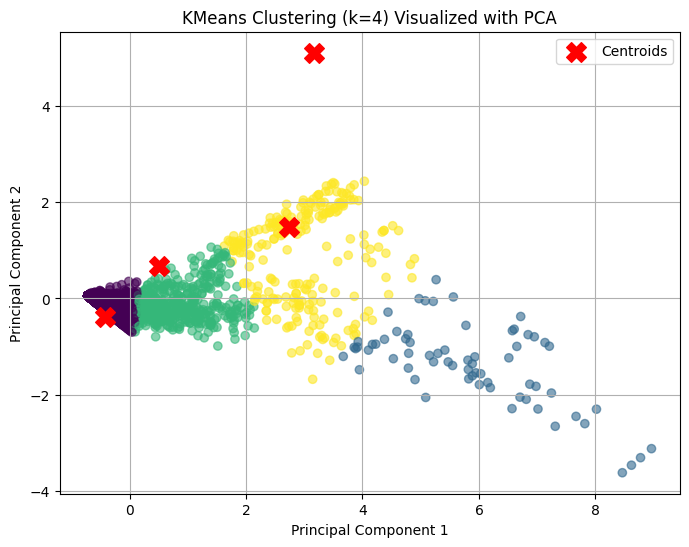

In [61]:
from sklearn.decomposition import PCA

# Apply KMeans with 4 clusters (based on your observation)
kmeans = KMeans(n_clusters=4, random_state=42)
clusters = kmeans.fit_predict(scaled_data)

# Reduce dimensionality to 2 components for visualization
pca = PCA(n_components=2)
pca_components = pca.fit_transform(scaled_data)

# Plot the clusters
plt.figure(figsize=(8, 6))
scatter = plt.scatter(pca_components[:, 0], pca_components[:, 1], c=clusters, cmap='viridis', alpha=0.6)
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], s=200, c='red', label='Centroids', marker='X')
plt.title('KMeans Clustering (k=4) Visualized with PCA')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend()
plt.grid(True)
plt.show()
